# Basic ML models

This notebook compares different ML models to predict the survival of cancer samples:

1. **unimodal** — using only clinical data (age, sexe, etc.)
2. **bimodal** — using clinical data and RNA-seq data (bulk, protein-coding genes)

Both kinds of models predict a **log partial hazard** (Cox linear predictor) for each sample. 
A higher log partial hazard score indicates a higher predicted risk of death, and therefore a shorter expected survival time.

In [28]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd
import sklearn as sk

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## EDA

In [22]:
clinical_data = pd.read_csv("../../data/coldata_essaiscliniques_vF.csv")
# clinical_data["BMI"] = clinical_data["Weight"] / (np.square(clinical_data["Height"]/100))
clinical_data.head()

,SampleID,Site,Indication,Nber_treatments,Treat_radio,Treat_immuno,Treat_angio,Treat_monoAb,Treat_chemo,Age,...,Weight,Height,Date_prelevement,Date_traitement,Death_status,OS_traitement,Prog_status,PFS_traitement,OS_prelevement,PFS_prelevement
0,01-001,Primary,LAPC,1,No,No,No,No,Yes,60,...,60.0,160,2023-03-14,2023-04-05,1,621,1,308,643,330
1,01-003,Primary,LAPC,1,No,No,No,No,Yes,59,...,75.0,180,2023-04-13,2023-06-01,1,501,1,442,550,491
2,01-004,Primary,LAPC,1,No,No,No,No,Yes,62,...,86.0,188,2023-04-26,2023-06-06,1,331,1,50,372,91
3,01-006,Primary,LAPC,1,No,No,No,No,Yes,74,...,82.0,165,2023-06-21,2023-07-27,1,495,1,476,531,512
4,01-007,Primary,LAPC,1,No,No,No,No,Yes,59,...,68.0,176,2023-08-07,2023-09-14,0,613,0,613,651,651


In [ ]:
px.scatter(clinical_data, x="OS_prelevement", y="PFS_prelevement", color="Indication", title="Distribution of OS and PFS by Cancer Type")
# one sample sah a negative PFS: that's not per se an error, as the patient progressed before the sampling

In [ ]:
px.box(clinical_data, x="Nber_treatments", y="OS_prelevement", color="Indication", title="Distribution of OS by Cancer Type and Number of Treatments")

In [13]:
px.box(clinical_data, x="Indication", y="OS_prelevement", color="Indication", title="Distribution of OS by Cancer Type")

In [15]:
px.histogram(clinical_data, "OS_prelevement", color="Indication", barmode="overlay", title="Histogram of OS by Cancer Type")

In [16]:
px.histogram(clinical_data, "PFS_prelevement", color="Indication", barmode="overlay", title="Histogram of PFS by Cancer Type")

In [18]:
px.scatter(clinical_data, x="Site", y="OS_prelevement")

In [19]:
px.box(clinical_data, x="Indication", y="OS_prelevement", color="Site", title="Distribution of OS by Cancer Type")

<Axes: xlabel='timeline'>

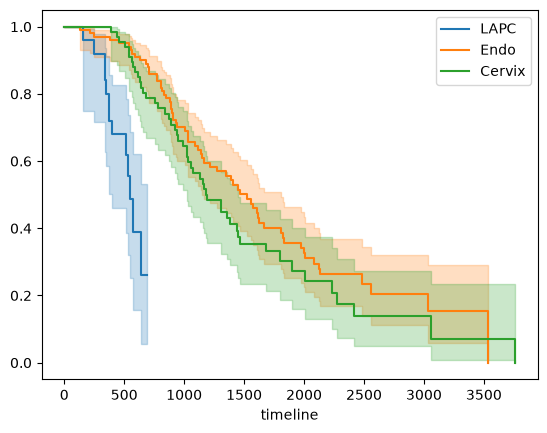

In [11]:
from lifelines import KaplanMeierFitter
km = KaplanMeierFitter() 
groups = clinical_data["Indication"]
i1 = (groups == "LAPC")
i2 = (groups == "Endo")
i3 = (groups == "Cervix")
km.fit(clinical_data.OS_prelevement[i1], clinical_data.Death_status[i1], label='LAPC')
a1 = km.plot()
km.fit(clinical_data.OS_prelevement[i2], clinical_data.Death_status[i2], label='Endo')
a2 = km.plot(ax = a1)
km.fit(clinical_data.OS_prelevement[i3], clinical_data.Death_status[i3], label='Cervix')
km.plot(ax = a2)

## Data preparation

In [23]:
# Removing columns that are IDs and that have a direct link with the variable of interest (OS_prelevement) but keeping the event column (for Cox model)
clinical_data_purged = clinical_data.copy(deep=True)
# clinical_data_purged = clinical_data_purged.loc[clinical_data_purged["Site"] == "Primary",] # to ease the predictions
clinical_data_purged = clinical_data_purged.drop(["SampleID", "Date_prelevement", "Date_traitement", "Prog_status", "OS_traitement", "PFS_traitement", "PFS_prelevement"], axis = 1)

In [24]:
# Separate target variable Y from features X
target_variable = "OS_prelevement"
event_variable = "Death_status"
X = clinical_data_purged.drop([target_variable, event_variable], axis = 1)
event_Cox = clinical_data_purged.loc[:,event_variable]
Y = clinical_data_purged.loc[:,target_variable]

# Divide dataset into Train set & Test set 
X_train, X_test, Y_train, Y_test, event_Cox_train, event_Cox_test = train_test_split(X, Y, event_Cox, test_size=0.2, random_state=42, stratify=clinical_data_purged.Indication)

In [25]:
X.head()

,Site,Indication,Nber_treatments,Treat_radio,Treat_immuno,Treat_angio,Treat_monoAb,Treat_chemo,Age,Sex,Weight,Height
0,Primary,LAPC,1,No,No,No,No,Yes,60,F,60.0,160
1,Primary,LAPC,1,No,No,No,No,Yes,59,M,75.0,180
2,Primary,LAPC,1,No,No,No,No,Yes,62,M,86.0,188
3,Primary,LAPC,1,No,No,No,No,Yes,74,F,82.0,165
4,Primary,LAPC,1,No,No,No,No,Yes,59,M,68.0,176


In [26]:
print("means of Y_train and mean : ", Y_train.mean(), Y_test.mean())
print("means of event_Cox_train and event_Cox_test : ", event_Cox_train.mean(), event_Cox_test.mean())

means of Y_train and mean :  1208.8376623376623 1256.4102564102564
means of event_Cox_train and event_Cox_test :  0.6428571428571429 0.717948717948718


In [29]:
# Transform X_train and X_test 

display(X.dtypes)
numeric_features = ["Nber_treatments", "Age", "Weight", "Height"]
categorical_features = ["Site", "Indication", "Treat_radio", "Treat_immuno", "Treat_angio", "Treat_monoAb", "Treat_chemo", "Sex"]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

Site                   str
Indication             str
Nber_treatments      int64
Treat_radio            str
Treat_immuno           str
Treat_angio            str
Treat_monoAb           str
Treat_chemo            str
Age                  int64
Sex                    str
Weight             float64
Height               int64
dtype: object

In [31]:
X_train[0:5]

array([[-0.51219932,  0.30291685,  0.44008583, -1.34330335,  0.        ,
         1.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ],
       [-0.51219932,  0.12520563,  0.13736465, -0.64347684,  0.        ,
         1.        ,  1.        ,  0.        ,  1.        ,  1.        ,
         0.        ,  0.        ,  0.        ],
       [ 2.48319417,  0.21406124, -1.86059513, -2.32306047,  0.        ,
         1.        ,  1.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.48626518, -0.40792803,  0.92443971,  0.05634967,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  1.        ,  0.        ],
       [-0.51219932,  0.83605051,  1.28770513, -0.50351154,  0.        ,
         1.        ,  1.        ,  0.        ,  1.        ,  1.        ,
         0.        ,  0.        ,  0.        ]])

## 1. Unimodal models

### a. linear regression

toto

### b. random forest

toto

### b. Cox model

toto

In [19]:
from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(clinical_data_purged, 'OS_prelevement', event_col='Death_status')
cph.print_summary()

ValueError: could not convert string to float: 'Metastasis'

## 2. Bimodal models

### a. toto

toto